### 3.5.10. Nonconvex Nonlinear Programs

$$
\min_{\mathbf{x}\in\mathcal{X}}\; f(\mathbf{x}),
\qquad f \text{ or } \mathcal{X} \text{ nonconvex}.
$$

$$
\text{KKT: necessary, not sufficient} \qquad\Longrightarrow\qquad d^\star \le p^\star \ \text{(relaxation lower bound)}.
$$

**Explanation:**

A nonlinear program is nonconvex when its objective or feasible set is not convex, and this single property removes the guarantees convex problems enjoy. There may be several local minima, the [KKT conditions](../03_Convex_Optimization/46_karush_kuhn_tucker_conditions.ipynb) are only necessary so they flag every stationary point, and a local solver returns whichever minimizer sits in the basin of its starting point. To judge how good a local solution is, one solves a convex relaxation or dual whose value $d^\star$ is a lower bound $d^\star \le p^\star$; the gap to the best feasible value certifies near-optimality. Certifying the true global optimum requires the [global optimization](../08_Global_and_Derivative_Free_Optimization/01_global_optimization.ipynb) methods, in contrast to the [convex NLPs](./09_convex_nonlinear_programs.ipynb) where any local optimum is already global.

**Numerical Example:**

$$
\min_x\; f(x) = x^4 - 4x^2 + x.
$$

The stationary points solve $f'(x) = 4x^3 - 8x + 1 = 0$, which has three real roots: two local minima near $x\approx -1.45$ and $x\approx 1.34$, separated by a local maximum near $x\approx 0.12$. Comparing objective values,
$$
f(-1.45) \approx -5.44 \quad(\text{global}),\qquad f(1.34) \approx -2.61 \quad(\text{local}),
$$
so a descent method started at $x_0=1$ converges to the inferior minimizer $x\approx 1.34$, while one started at $x_0=-1$ reaches the global minimizer. The problem being nonconvex, the starting point decides which solution is found.

In [1]:
import sympy as sp

x = sp.symbols("x", real=True)
objective = x**4 - 4*x**2 + x
first_derivative = sp.diff(objective, x)
second_derivative = sp.diff(objective, x, 2)

stationary_points = sorted(float(root) for root in sp.Poly(first_derivative, x).nroots() if root.is_real)
classified = [(round(point, 3),
               "min" if float(second_derivative.subs(x, point)) > 0 else "max",
               round(float(objective.subs(x, point)), 3))
              for point in stationary_points]
local_minima = [item for item in classified if item[1] == "min"]
global_minimizer = min(local_minima, key=lambda item: item[2])

for location, kind, value in classified:
    print(f"x = {location:+.3f}  ({kind})  f = {value:+.3f}")
print("global minimizer:", global_minimizer[0], "value", global_minimizer[2])

x = -1.473  (min)  f = -5.444
x = +0.126  (max)  f = +0.063
x = +1.347  (min)  f = -2.619
global minimizer: -1.473 value -5.444


**Equivalent casadi implementation:**

In [2]:
import casadi as ca

decision_variable = ca.SX.sym("x")
objective = decision_variable**4 - 4*decision_variable**2 + decision_variable
solver = ca.nlpsol("solver", "ipopt", {"x": decision_variable, "f": objective},
                   {"ipopt.print_level": 0, "print_time": 0, "ipopt.sb": "yes"})

for start in (-1.0, 1.0):
    solution = solver(x0=start)
    print(f"start {start:+.1f} -> local minimizer {float(solution['x']):+.3f}, value {float(solution['f']):+.3f}")

start -1.0 -> local minimizer -1.473, value -5.444
start +1.0 -> local minimizer +1.347, value -2.619


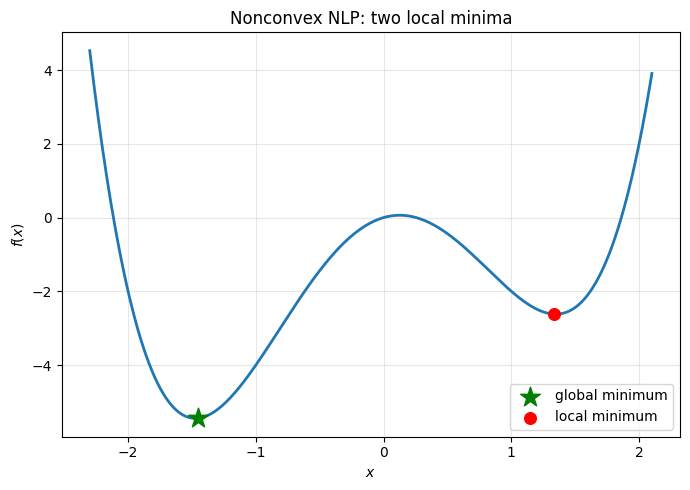

In [3]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(-2.3, 2.1, 400)
values = grid**4 - 4*grid**2 + grid
plt.figure(figsize=(7, 5))
plt.plot(grid, values, linewidth=2)
plt.scatter([-1.454], [-5.44], color="green", marker="*", s=220, zorder=3, label="global minimum")
plt.scatter([1.334], [-2.61], color="red", s=70, zorder=3, label="local minimum")
plt.xlabel("$x$"); plt.ylabel("$f(x)$"); plt.title("Nonconvex NLP: two local minima")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

**References:**

[📘 Bertsekas, D. P. (1999). *Nonlinear Programming* (2nd ed.). Athena Scientific.](https://www.athenasc.com/nonlinbook.html)  
[📘 Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press.](https://web.stanford.edu/~boyd/cvxbook/)

---

[⬅️ Previous: Convex Nonlinear Programs](./09_convex_nonlinear_programs.ipynb) | [Next: Sequential Quadratic Programming (SQP) ➡️](./11_sequential_quadratic_programming.ipynb)